## Load Data and Prepare for Analysis

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Point to the correct folder
data_path = "outputs/ensemble"

print(f"Listing files in {os.path.abspath(data_path)}:")
try:
    for f in os.listdir(data_path):
        print(f" - {f}")
except FileNotFoundError:
    print(f"Error: Directory {os.path.abspath(data_path)} not found.")
print("-----------------------------------------")

dfs = []

for i in range(1, 10):
    file_name = f"predictions_subject_{i}.csv"
    file_path = os.path.join(data_path, file_name)
    try:
        df = pd.read_csv(file_path)
        dfs.append(df)
        print(f"Successfully loaded {file_name}")
    except FileNotFoundError:
        print(f"Error: {file_name} not found at {file_path}.")
    except Exception as e:
        print(f"Error loading {file_name}: {e}")

if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    print("\nAll CSV files concatenated successfully. Head of the combined DataFrame:")
    display(combined_df.head())
    print(f"Total rows in combined DataFrame: {len(combined_df)}")
else:
    combined_df = pd.DataFrame()
    print("No data loaded.")

Listing files in /Users/kevinzhou/Desktop/kev-personal/jr-academy/m.i.n.d/outputs/ensemble:
 - predictions_subject_7.csv
 - predictions_subject_6.csv
 - predictions_subject_4.csv
 - predictions_subject_5.csv
 - predictions_subject_1.csv
 - ensemble_summary.csv
 - predictions_subject_2.csv
 - predictions_subject_3.csv
 - ensemble_subject_results.csv
 - predictions_subject_8.csv
 - predictions_subject_9.csv
-----------------------------------------
Successfully loaded predictions_subject_1.csv
Successfully loaded predictions_subject_2.csv
Successfully loaded predictions_subject_3.csv
Successfully loaded predictions_subject_4.csv
Successfully loaded predictions_subject_5.csv
Successfully loaded predictions_subject_6.csv
Successfully loaded predictions_subject_7.csv
Successfully loaded predictions_subject_8.csv
Successfully loaded predictions_subject_9.csv

All CSV files concatenated successfully. Head of the combined DataFrame:


,subject,trial_index,y_true,lda_pred,svm_pred,rf_pred,ensemble_pred,ensemble_pred_thresholded,ensemble_max_prob,ensemble_confident,p_ens_c0,p_ens_c1,p_ens_c2,p_ens_c3
0,1,0,3,3,3,3,3,3,0.574858,1,0.003693,0.001300,0.420150,0.574858
1,1,1,2,2,2,2,2,2,0.717621,1,0.004143,0.003102,0.717621,0.275134
2,1,2,1,1,1,1,1,1,0.926491,1,0.049809,0.926491,0.022003,0.001697
3,1,3,0,0,0,3,0,0,0.621590,1,0.621590,0.006372,0.159865,0.212173
4,1,4,0,3,3,3,3,3,0.700466,1,0.097926,0.002993,0.198615,0.700466


Total rows in combined DataFrame: 2565


## Define Class Labels and Plotting Function

In [50]:
# Define class labels
class_labels = {0: 'Left Hand', 1: 'Right Hand', 2: 'Feet', 3: 'Tongue'}

def plot_confusion_matrix(y_true, y_pred, labels, title, filename):
    """Plots and saves a confusion matrix with accuracy percentages per class."""

    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(labels.keys()))

    # Normalize to show accuracy percentage for each true class
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=labels.values(), yticklabels=labels.values())
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()

    # Create directory for plots if it doesn't exist
    os.makedirs('confusion_matrices', exist_ok=True)
    save_path = os.path.join('confusion_matrices', filename)
    plt.savefig(save_path)
    plt.show()


## Generate and Save Confusion Matrices

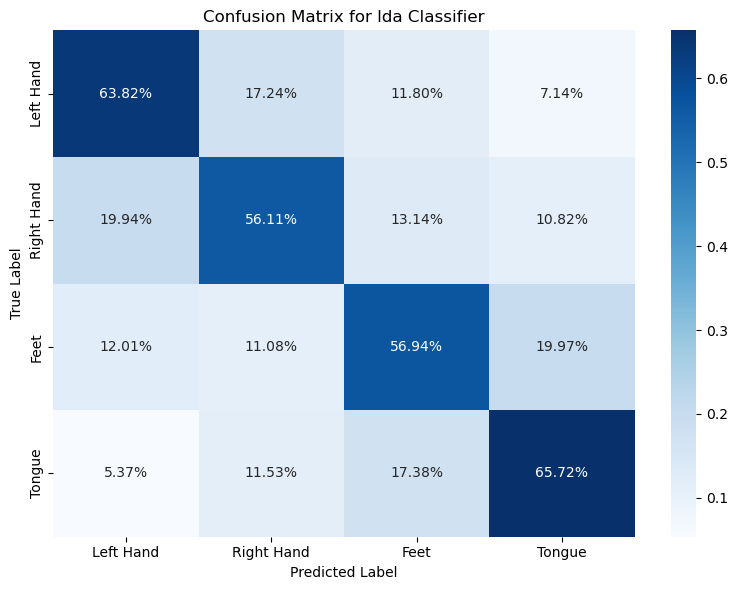

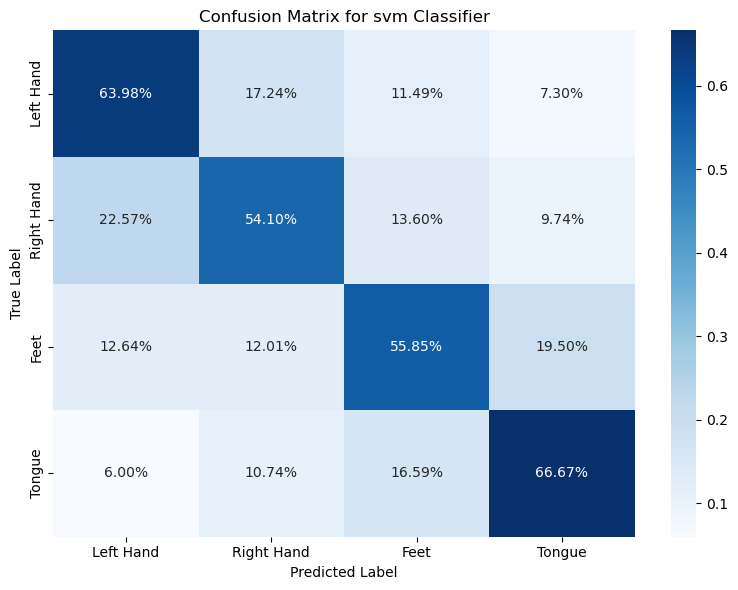

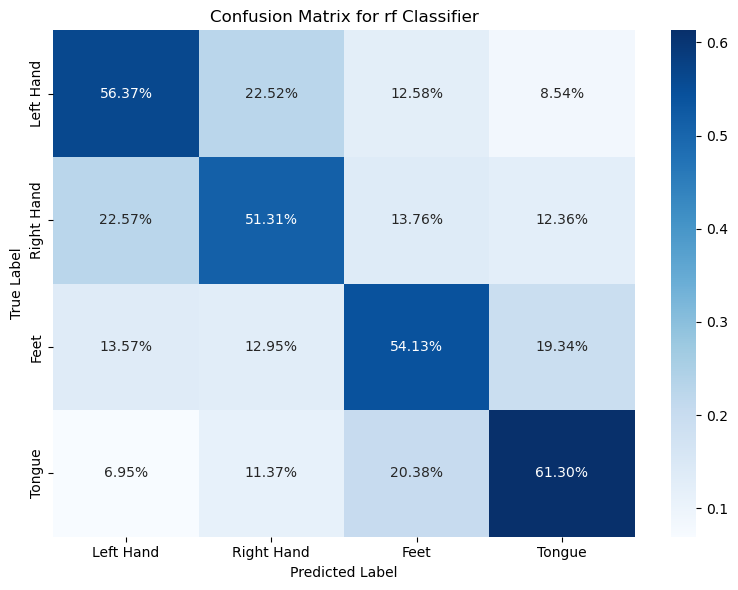

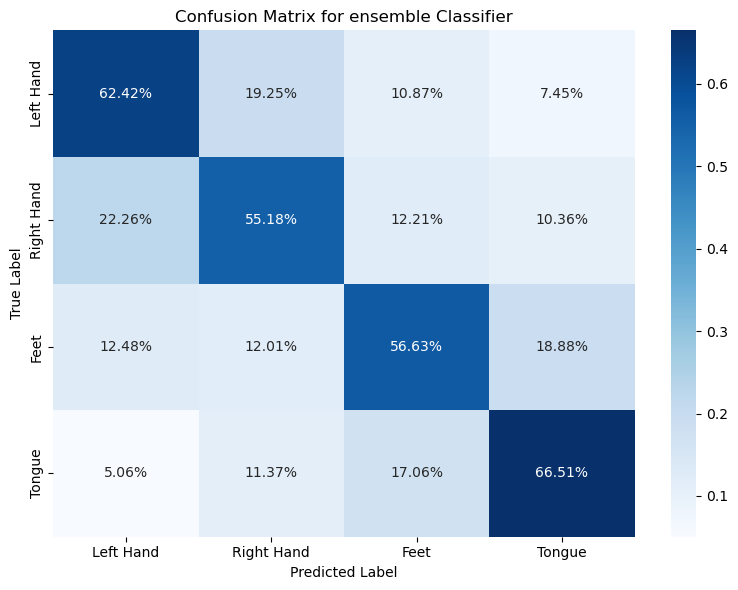

In [51]:
if not combined_df.empty:
    y_true = combined_df['y_true']
    prediction_columns = ['lda_pred', 'svm_pred', 'rf_pred', 'ensemble_pred']

    for col in prediction_columns:
        if col in combined_df.columns:
            y_pred = combined_df[col]
            plot_confusion_matrix(
                y_true,
                y_pred,
                class_labels,
                f'Confusion Matrix for {col.replace("_pred", "")} Classifier',
                f'confusion_matrix_{col}.png'
            )
        else:
            print(f"Warning! Prediction column '{col}' not found in the DataFrame.")
else:
    print("Cannot generate confusion matrices")

## Calculate Per-Subject Accuracy and Plot

In [52]:
from sklearn.metrics import accuracy_score

# Initialize dictionary for models accuracies
models_acc = {}

# Get unique subjects
unique_subjects = combined_df['subject'].unique()

prediction_columns = ['lda_pred', 'svm_pred', 'rf_pred', 'ensemble_pred']

# Initialize a new dictionary to store per-subject accuracies, named model_acc as requested
model_acc = {}

for subject_id in unique_subjects:
    subject_df = combined_df[combined_df['subject'] == subject_id]
    y_true_subject = subject_df['y_true']

    model_acc[subject_id] = {}
    for col in prediction_columns:
        if col in subject_df.columns:
            y_pred_subject = subject_df[col]
            accuracy = accuracy_score(y_true_subject, y_pred_subject)
            model_acc[subject_id][col.replace('_pred', '')] = accuracy
        else:
            print(f"Warning: Prediction column '{col}' not found for subject {subject_id}.")

# Convert to DataFrame for plotting
accuracy_df = pd.DataFrame.from_dict(model_acc, orient='index')
accuracy_df.index.name = 'subject'
accuracy_df.reset_index(inplace=True)

display(accuracy_df.head())


,subject,lda,svm,rf,ensemble
0,1,0.743056,0.760417,0.729167,0.753472
1,2,0.649306,0.631944,0.545139,0.614583
2,3,0.763889,0.767361,0.763889,0.767361
3,4,0.357639,0.413194,0.357639,0.402778
4,5,0.416667,0.395833,0.350694,0.416667


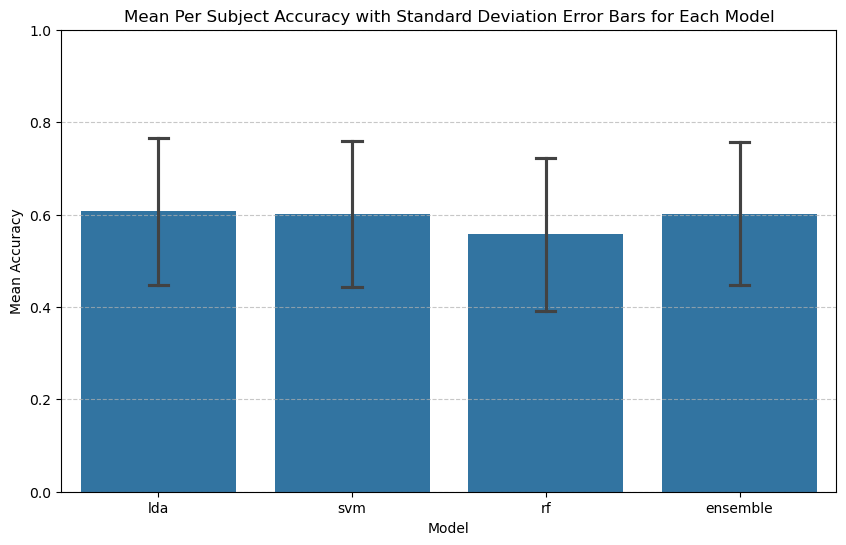

In [53]:
# Melt DataFrame to long format for seaborn barplot
accuracy_melted = accuracy_df.melt(id_vars=['subject'], var_name='model', value_name='accuracy')

plt.figure(figsize=(10, 6))
sns.barplot(x='model', y='accuracy', data=accuracy_melted, capsize=.1, errorbar='sd')
plt.title('Mean Per Subject Accuracy with Standard Deviation Error Bars for Each Model')
plt.xlabel('Model')
plt.ylabel('Mean Accuracy')
plt.ylim(0, 1) # Accuracy from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Create directory for plots if it doesn't exist
os.makedirs('accuracy_plots', exist_ok=True)
save_path = os.path.join('accuracy_plots', 'model_accuracy_bar_chart.png')
plt.savefig(save_path)
plt.show()


## Load Key Numbers and Generate Formatted Accuracy Table

In [56]:
import os

key_numbers_path = "outputs/key_numbers"

# Load the new CSV files
try:
    key_numbers_per_subject_df = pd.read_csv(
        os.path.join(key_numbers_path, "key_numbers_per_subject.csv")
    )
    display(key_numbers_per_subject_df.head())
except FileNotFoundError:
    print(f"Error: key_numbers_per_subject.csv not found in {os.path.abspath(key_numbers_path)}.")
except Exception as e:
    print(f"Error loading key_numbers_per_subject.csv: {e}")

try:
    key_numbers_summary_df = pd.read_csv(
        os.path.join(key_numbers_path, "key_numbers_summary.csv")
    )
    display(key_numbers_summary_df.head())
except FileNotFoundError:
    print(f"Error: key_numbers_summary.csv not found in {os.path.abspath(key_numbers_path)}.")
except Exception as e:
    print(f"Error loading key_numbers_summary.csv: {e}")

# Prepare the accuracy table from accuracy_df
formatted_accuracy_table = accuracy_df.set_index('subject').copy()

# Calculate mean and standard deviation for each model
mean_accuracies = formatted_accuracy_table.mean().rename('Mean')
std_accuracies = formatted_accuracy_table.std().rename('Std Dev')

# Append mean and standard deviation rows
formatted_accuracy_table = pd.concat(
    [formatted_accuracy_table, pd.DataFrame([mean_accuracies, std_accuracies])]
)

# Format for better display
formatted_accuracy_table = formatted_accuracy_table.map(lambda x: f'{x:.4f}')

display(formatted_accuracy_table)

,Subject,LDA Acc,SVM Acc,RF Acc,Ensemble Acc (all),Ensemble Acc (confident),Ensemble Coverage,Best Single,Best Single Acc,Ensemble - Best (all)
0,S1,0.742892,0.753176,0.735874,0.725694,0.758772,0.791667,SVM,0.753176,-0.027482
1,S2,0.649546,0.614459,0.566062,0.652778,0.768362,0.614583,LDA,0.649546,0.003232
2,S3,0.756443,0.767090,0.767030,0.715278,0.781818,0.763889,SVM,0.767090,-0.051812
3,S4,0.357471,0.419903,0.360799,0.399306,0.568627,0.177083,SVM,0.419903,-0.020597
4,S5,0.416394,0.388748,0.340169,0.388889,0.607143,0.097222,LDA,0.416394,-0.027505


,Metric,Value
0,Mean LDA accuracy,0.604505759638851
1,Mean SVM accuracy,0.5987770647641589
2,Mean RF accuracy,0.5594455938406332
3,Mean Best-Single accuracy,0.6141796352020186
4,Mean Ensemble accuracy (all),0.569354491614928


,lda,svm,rf,ensemble
1,0.7431,0.7604,0.7292,0.7535
2,0.6493,0.6319,0.5451,0.6146
3,0.7639,0.7674,0.7639,0.7674
4,0.3576,0.4132,0.3576,0.4028
5,0.4167,0.3958,0.3507,0.4167
6,0.4545,0.4336,0.3811,0.4266
7,0.7326,0.7153,0.6771,0.7222
8,0.7419,0.7563,0.6918,0.7455
9,0.5993,0.5368,0.5221,0.5662
Mean,0.6065,0.6012,0.5576,0.6017


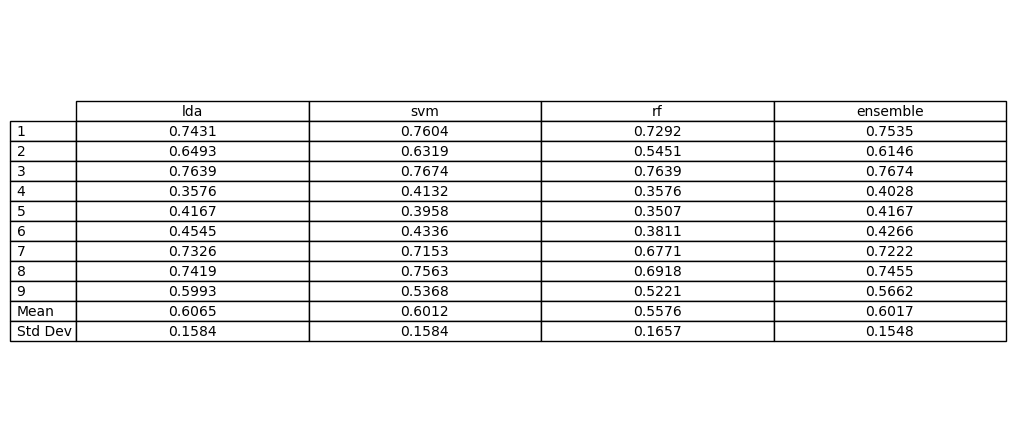

In [57]:
import matplotlib.pyplot as plt
from pandas.plotting import table

# Save the formatted table as CSV
csv_save_path = os.path.join('accuracy_plots', 'formatted_accuracy_table.csv')
formatted_accuracy_table.to_csv(csv_save_path)

# Save the formatted table as PNG
fig, ax = plt.subplots(figsize=(10, len(formatted_accuracy_table) * 0.5))
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

tbl = table(ax, formatted_accuracy_table, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)

png_save_path = os.path.join('accuracy_plots', 'formatted_accuracy_table.png')
plt.savefig(png_save_path, bbox_inches='tight', pad_inches=0.5)
plt.show()


## Statistical Analysis: Paired t-test

In [58]:
from scipy import stats

# Ensure 'subject' in key_numbers_per_subject_df is numeric for merging
key_numbers_per_subject_df['Subject'] = key_numbers_per_subject_df['Subject'].str.replace('S', '').astype(int)

# Merge accuracy_df with key_numbers_per_subject_df to get 'Best Single Acc' per subject
# Rename 'subject' to 'Subject' in accuracy_df to match key_numbers_per_subject_df for merging
merged_accuracies = pd.merge(accuracy_df, key_numbers_per_subject_df[['Subject', 'Best Single Acc']],
                           left_on='subject', right_on='Subject', how='inner')

# Extract the accuracy scores for ensemble and best single model
ensemble_scores = merged_accuracies['ensemble']
best_single_scores = merged_accuracies['Best Single Acc']

# Perform the paired t-test
t_statistic, p_value = stats.ttest_rel(ensemble_scores, best_single_scores)

print(f"\nPaired t-test results between Ensemble and Best Single Model:")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"Since p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference between the Ensemble and Best Single Model.")
    if t_statistic > 0:
        print("The Ensemble model performs significantly better than the Best Single model.")
    else:
        print("The Best Single model performs significantly better than the Ensemble model.")
else:
    print(f"Since p-value ({p_value:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference between the Ensemble and Best Single Model.")


Paired t-test results between Ensemble and Best Single Model:
T-statistic: -2.7192
P-value: 0.0263
Since p-value (0.0263) < alpha (0.05), we reject the null hypothesis.
There is a statistically significant difference between the Ensemble and Best Single Model.
The Best Single model performs significantly better than the Ensemble model.
